# PHASE 1: TIỀN XỬ LÝ DỮ LIỆU NETWORK
## Hệ thống phát hiện tấn công DDoS trong mạng IoT

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

os.makedirs('Phase1_Network_Data', exist_ok=True)
os.makedirs('Phase1_Network_Models', exist_ok=True)
os.makedirs('Images', exist_ok=True)

print("=" * 60)
print("PHASE 1: TIỀN XỬ LÝ DỮ LIỆU NETWORK")
print("=" * 60)

PHASE 1: TIỀN XỬ LÝ DỮ LIỆU NETWORK


## BƯỚC 1: LOAD DỮ LIỆU

In [2]:
print("\nBƯỚC 1: LOAD DỮ LIỆU")
print("-" * 40)

train_df = pd.read_csv('Network/UNSW_NB15_training-set.csv')
test_df = pd.read_csv('Network/UNSW_NB15_testing-set.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")


BƯỚC 1: LOAD DỮ LIỆU
----------------------------------------
Train shape: (82332, 45)
Test shape: (175341, 45)


## BƯỚC 2: XỬ LÝ FEATURES

In [3]:
print("\nBƯỚC 2: XỬ LÝ FEATURES")
print("-" * 40)

cols_to_drop = ['id', 'attack_cat', 'label']
cols_to_drop = [col for col in cols_to_drop if col in train_df.columns]

X_train = train_df.drop(cols_to_drop, axis=1)
y_train = train_df['label']
X_test = test_df.drop(cols_to_drop, axis=1)
y_test = test_df['label']

print(f"Features: {X_train.shape[1]}")
print(f"Dropped: {cols_to_drop}")

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()


BƯỚC 2: XỬ LÝ FEATURES
----------------------------------------
Features: 42
Dropped: ['id', 'attack_cat', 'label']


## VISUALIZATION: NETWORK DATA ANALYSIS

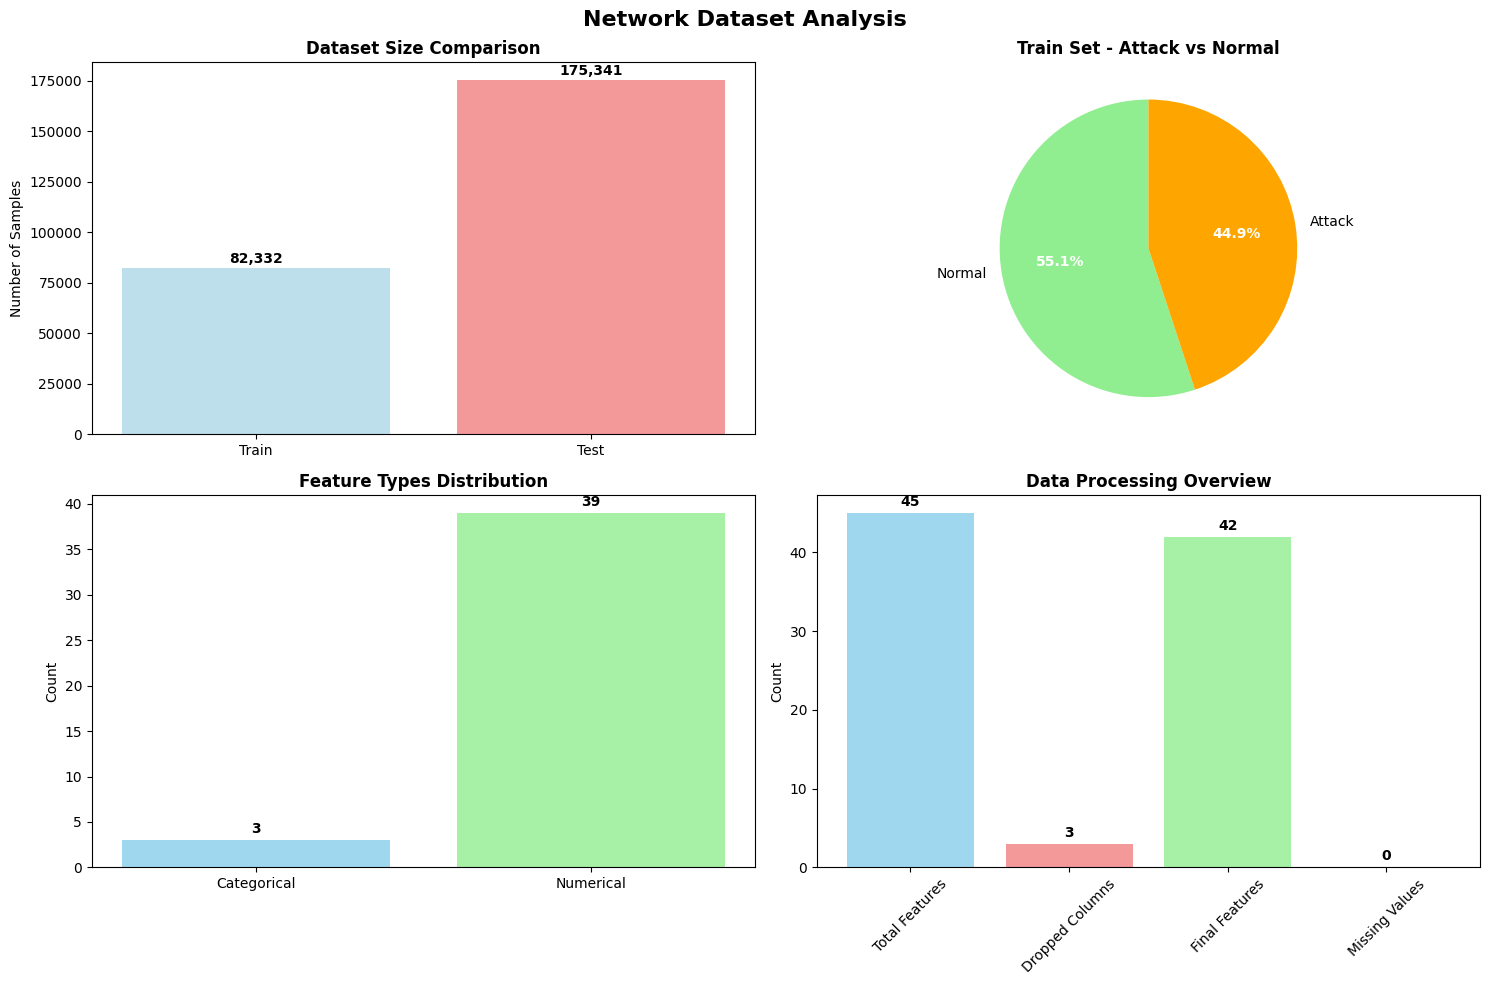


Network Dataset Summary:
Train samples: 82,332
Test samples: 175,341
Features after processing: 42
Attack ratio in train: 55.1%


In [4]:
# Network dataset visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Network Dataset Analysis', fontsize=16, fontweight='bold')

# 1. Train vs Test size comparison
ax1 = axes[0, 0]
dataset_sizes = ['Train', 'Test']
sizes = [len(train_df), len(test_df)]
colors = ['lightblue', 'lightcoral']
bars = ax1.bar(dataset_sizes, sizes, color=colors, alpha=0.8)
ax1.set_title('Dataset Size Comparison', fontweight='bold')
ax1.set_ylabel('Number of Samples')
for bar, size in zip(bars, sizes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
             f'{size:,}', ha='center', va='bottom', fontweight='bold')

# 2. Binary classification distribution
ax2 = axes[0, 1]
train_labels = train_df['label'].value_counts()
colors = ['lightgreen', 'orange']
wedges, texts, autotexts = ax2.pie(train_labels.values, labels=['Normal', 'Attack'], 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Train Set - Attack vs Normal', fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 3. Feature types distribution
ax3 = axes[1, 0]
feature_types = ['Categorical', 'Numerical']
feature_counts = [len(categorical_cols), len(numerical_cols)]
colors = ['skyblue', 'lightgreen']
bars = ax3.bar(feature_types, feature_counts, color=colors, alpha=0.8)
ax3.set_title('Feature Types Distribution', fontweight='bold')
ax3.set_ylabel('Count')
for bar, count in zip(bars, feature_counts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(count), ha='center', va='bottom', fontweight='bold')

# 4. Data quality metrics
ax4 = axes[1, 1]
quality_metrics = ['Total Features', 'Dropped Columns', 'Final Features', 'Missing Values']
quality_values = [train_df.shape[1], len(cols_to_drop), X_train.shape[1], X_train.isnull().sum().sum()]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange']
bars = ax4.bar(quality_metrics, quality_values, color=colors, alpha=0.8)
ax4.set_title('Data Processing Overview', fontweight='bold')
ax4.set_ylabel('Count')
ax4.tick_params(axis='x', rotation=45)
for bar, value in zip(bars, quality_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(value), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('Images/Phase1_Network_data_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nNetwork Dataset Summary:")
print(f"Train samples: {len(train_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Features after processing: {X_train.shape[1]}")
print(f"Attack ratio in train: {train_df['label'].mean()*100:.1f}%")

## BƯỚC 3: ENCODE CATEGORICAL FEATURES

In [5]:
print("\nBƯỚC 3: ENCODE CATEGORICAL FEATURES")
print("-" * 40)

feature_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    
    test_values = X_test[col].astype(str).values
    class_to_idx = {cls: idx for idx, cls in enumerate(le.classes_)}
    X_test[col] = np.array([class_to_idx.get(val, 0) for val in test_values])
    
    feature_encoders[col] = le
    unseen = np.sum([val not in class_to_idx for val in test_values])
    print(f"  {col}: {len(le.classes_)} classes, {unseen} unseen")


BƯỚC 3: ENCODE CATEGORICAL FEATURES
----------------------------------------
  proto: 131 classes, 16 unseen
  service: 13 classes, 0 unseen
  state: 7 classes, 15 unseen


## BƯỚC 4: XỬ LÝ MISSING VALUES

In [6]:
print("\nBƯỚC 4: XỬ LÝ MISSING VALUES")
print("-" * 40)

for col in numerical_cols:
    if X_train[col].isnull().sum() > 0:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_test[col].fillna(median_val, inplace=True)

print(f"Missing after fill - Train: {X_train.isnull().sum().sum()}, Test: {X_test.isnull().sum().sum()}")


BƯỚC 4: XỬ LÝ MISSING VALUES
----------------------------------------
Missing after fill - Train: 0, Test: 0


## BƯỚC 5: CHUẨN HÓA DỮ LIỆU

In [7]:
print("\nBƯỚC 5: CHUẨN HÓA DỮ LIỆU")
print("-" * 40)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print(f"Scaled train: {X_train_scaled.shape}")
print(f"Scaled test: {X_test_scaled.shape}")


BƯỚC 5: CHUẨN HÓA DỮ LIỆU
----------------------------------------
Scaled train: (82332, 42)
Scaled test: (175341, 42)


## BƯỚC 6: LƯU DỮ LIỆU

In [8]:
print("\nBƯỚC 6: LƯU DỮ LIỆU")
print("-" * 40)

X_train_scaled.to_csv('Phase1_Network_Data/X_train_processed.csv', index=False)
X_test_scaled.to_csv('Phase1_Network_Data/X_test_processed.csv', index=False)
pd.DataFrame(y_train, columns=['label']).to_csv('Phase1_Network_Data/y_train_processed.csv', index=False)
pd.DataFrame(y_test, columns=['label']).to_csv('Phase1_Network_Data/y_test_processed.csv', index=False)

with open('Phase1_Network_Models/network_feature_encoders.pkl', 'wb') as f:
    pickle.dump(feature_encoders, f)
with open('Phase1_Network_Models/network_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Đã lưu tất cả files")


BƯỚC 6: LƯU DỮ LIỆU
----------------------------------------
✅ Đã lưu tất cả files


In [9]:
print("\n" + "=" * 60)
print("HOÀN THÀNH PHASE 1 NETWORK!")
print("=" * 60)
print(f"Features: {X_train_scaled.shape[1]}")
print(f"Classes: 2 (Normal, Attack)")
print(f"Train: {len(X_train_scaled)}, Test: {len(X_test_scaled)}")


HOÀN THÀNH PHASE 1 NETWORK!
Features: 42
Classes: 2 (Normal, Attack)
Train: 82332, Test: 175341
